# Configurando os exemplos de rede (Setting up the network examples)

In [59]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
%matplotlib inline

In [60]:
graph_a = nx.DiGraph()
graph_b = nx.DiGraph()
graph_c = nx.DiGraph()
nodes = range(1,6)
edges_ok = [(1,2),(1,3),(2,3),(3,1),(3,2),(3,4),(4,5),
            (4,6),(5,4),(5,6),(6,5),(6,1)]
edges_dead_end = [(1,2),(1,3),(3,1),(3,2),(3,4),(4,5),
                  (4,6),(5,4),(5,6),(6,5),(6,1)]
edges_trap = [(1,2),(1,3),(2,3),(3,1),(3,2),(3,4),(4,5),
              (4,6),(5,4),(5,6),(6,5)]
graph_a.add_nodes_from(nodes)
graph_a.add_edges_from(edges_ok)
graph_b.add_nodes_from(nodes)
graph_b.add_edges_from(edges_dead_end)
graph_c.add_nodes_from(nodes)
graph_c.add_edges_from(edges_trap)

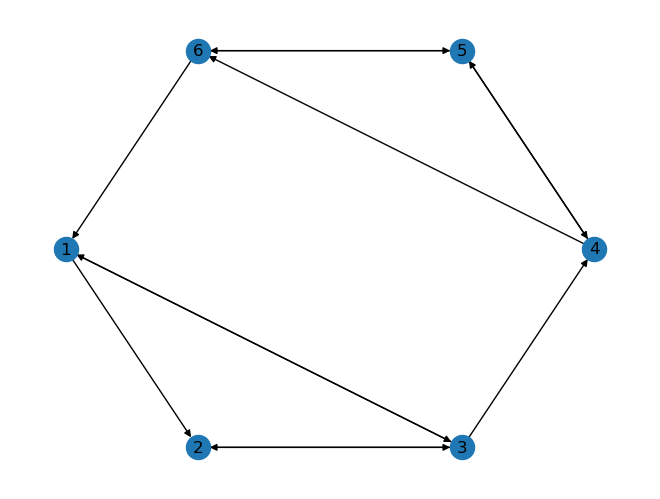

In [61]:
np.random.seed(2)
positions = nx.shell_layout(graph_a)
nx.draw(graph_a, positions, arrows=True, with_labels=True)
plt.show()

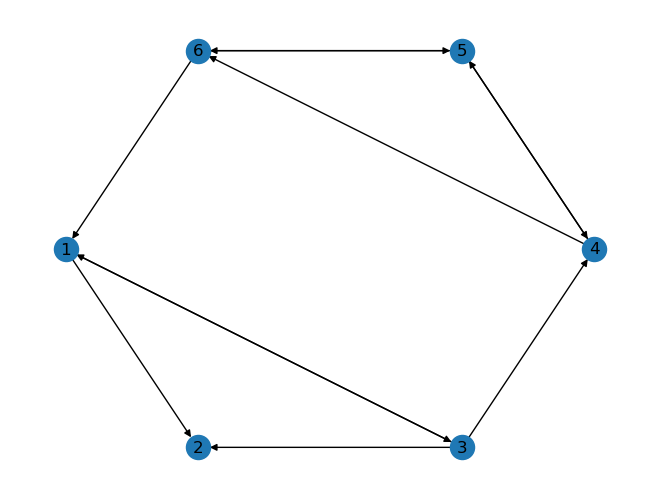

In [62]:
np.random.seed(2)
positions = nx.shell_layout(graph_b)
nx.draw(graph_b, positions, arrows=True, with_labels=True)
plt.show()

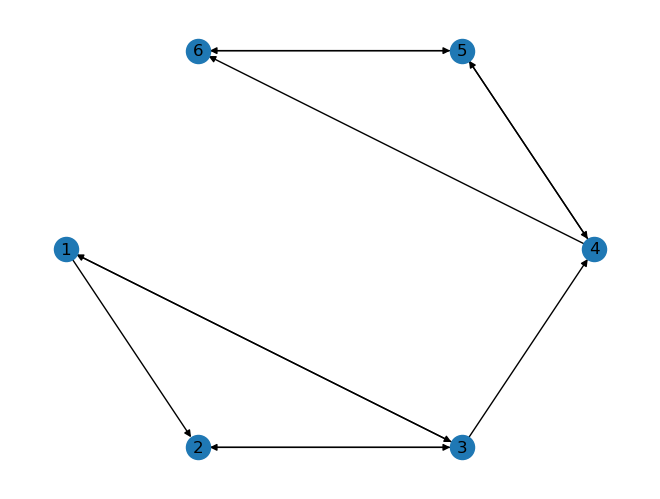

In [63]:
np.random.seed(2)
positions = nx.shell_layout(graph_c)
nx.draw(graph_c, positions, arrows=True, with_labels=True)
plt.show()

# Implementação ingênua de um PageRank (A PageRank's naive implementation)

 Matriz de transição

**Colunas**: Contêm o nó no qual um usuário web está.

**Linhas**: Contêm a probabilidade de um usuário visitar outros nós por causa de links de saída.

In [64]:
def initialize_page_rank(graph):
    nodes = len(graph)
    matrix = nx.to_numpy_matrix(graph)
    outbound = np.squeeze(np.asarray(np.sum(matrix, axis=1)))
    prob_outbound = np.array(
        [1.0/count if count>0 else 0.0 for count in outbound])
    graph = np.asarray(np.multiply(matrix.T, prob_outbound))
    points = np.ones(nodes) / float(nodes)
    if np.min(np.sum(graph,axis=0)) < 1.0:
        print('Warning: graph is substochastic')
    return graph, points

In [65]:
graph, probabilities = initialize_page_rank(graph_a)
print(graph)

[[0.         0.         0.33333333 0.         0.         0.5       ]
 [0.5        0.         0.33333333 0.         0.         0.        ]
 [0.5        1.         0.         0.         0.         0.        ]
 [0.         0.         0.33333333 0.         0.5        0.        ]
 [0.         0.         0.         0.5        0.         0.5       ]
 [0.         0.         0.         0.5        0.5        0.        ]]


In [66]:
from scipy import sparse
sparse_graph = sparse.csr_matrix(graph)
print(sparse_graph)

  (0, 2)	0.3333333333333333
  (0, 5)	0.5
  (1, 0)	0.5
  (1, 2)	0.3333333333333333
  (2, 0)	0.5
  (2, 1)	1.0
  (3, 2)	0.3333333333333333
  (3, 4)	0.5
  (4, 3)	0.5
  (4, 5)	0.5
  (5, 3)	0.5
  (5, 4)	0.5


In [67]:
print(probabilities)

[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]


In [68]:
print(np.dot(graph, probabilities))

[0.13888889 0.13888889 0.25       0.13888889 0.16666667 0.16666667]


# Apresentando tédio (Introducing boredom)

In [69]:
def page_rank_naive(graph, iters = 50):
    graph, probabilities = initialize_page_rank(graph)
    for index in range(iters):
        probabilities = np.dot(graph,probabilities)
    return np.round(probabilities,3)

print(page_rank_naive(graph_a))

[0.154 0.154 0.231 0.154 0.154 0.154]


In [70]:
print(page_rank_naive(graph_b))

[0. 0. 0. 0. 0. 0.]


In [71]:
print(page_rank_naive(graph_c))

[0.    0.    0.    0.222 0.444 0.333]


In [72]:
def page_rank_teleporting(graph, iters = 50, alpha=0.85, rounding=3):
    graph, probabilities = initialize_page_rank(graph)
    u = np.ones(len(probabilities)) / float(len(probabilities))
    for index in range(iters):
        probabilities = alpha * np.dot(graph,probabilities) + (1.0 - alpha) * u
    return np.round(probabilities / np.sum(probabilities), rounding)

print('Graph A:', page_rank_teleporting(graph_a, 
                                    rounding=8))
print('Graph B:', page_rank_teleporting(graph_b, 
                                    rounding=8))
print('Graph C:', page_rank_teleporting(graph_c, 
                                    rounding=8))

Graph A: [0.15477863 0.15346061 0.22122243 0.15477863 0.15787985 0.15787985]
Graph B: [0.16502904 0.14922238 0.11627717 0.16502904 0.20222118 0.20222118]
Graph C: [0.0598128  0.08523323 0.12286869 0.18996342 0.30623677 0.23588508]


In [73]:
# http://networkx.readthedocs.io/en/networkx-1.11/reference/generated/networkx.algorithms.link_analysis.pagerank_alg.pagerank.html
nx.pagerank(graph_a, alpha=0.85)

# https://moz.com/search-ranking-factors
# http://www.searchmetrics.com/knowledge-base/ranking-factors/

{1: 0.1547789249415197,
 2: 0.15346020566289406,
 3: 0.22122243782705608,
 4: 0.1547789249415197,
 5: 0.15787975331350507,
 6: 0.15787975331350507}